# 난임 임신성공 예측 — LightGBM 베이스라인 v1 (리크 안전판)

> 코드 리뷰 반영본. 핵심 변경: **`fit_preprocessor`(train만 fit) → `transform`(적용만)** 구조로 바꿔, 평가(test) 데이터가 학습 파이프라인에 들어가지 않음이 **코드상 자명**해짐.
>
> **반영된 리뷰 항목**
> - **#0·#1 [규정 위반 수정]** 명목형 인코딩을 train+test concat fit → **train categories만 fit**, test엔 적용만(미등장 범주 → -1). 멀티핫/순서형/비율/플래그는 행 단위라 그대로 유지.
> - **#2** ablation을 **multi-seed(mean±std)** 로 — Δ가 std 안에 묻히면 "차이 없음".
> - **#3** `총 임신 횟수·총 출산 횟수` **누수 검증** — 중요도 순위 출력 + `DROP_HISTORY_LEAK` 토글로 제외 시 AUC 변화 확인.
> - **#4** valid Dataset에 `reference=dtr` (bin/범주 매핑 상속).
> - **#5** 죽은/초희소 컬럼 **train 기준 자동 감지** (하드코딩 제거).
> - **#6** 멀티핫 vocab **train에서 추출** + test 커버리지 경고.
> - **#7** 나이 매핑 **컬럼별 분리**(시술당시/기증자) + 미매핑 경고.
> - **#8** `_safe_div` Series 반환(인덱스 안전).
> - **#9** 평가지표 **ROC-AUC 확정** — 현 코드 그대로.
>
> ⚠️ 타깃 인코딩을 나중에 도입하면: test 제외는 기본, **CV fold 내부에서 train fold로만 fit**해야 함(전체 train fit도 누수). 지금 코드엔 없음.

## 1. 셋업

In [1]:
import re, os, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
pd.set_option("display.max_columns", 200)
def setup_korean_font():
    try:
        import koreanize_matplotlib; return "koreanize_matplotlib"
    except Exception: pass
    from matplotlib import font_manager
    for cand in ["NanumGothic","Malgun Gothic","AppleGothic","NanumBarunGothic"]:
        if any(cand in f.name for f in font_manager.fontManager.ttflist):
            matplotlib.rcParams["font.family"]=cand; matplotlib.rcParams["axes.unicode_minus"]=False; return cand
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("폰트:", setup_korean_font() or "미설정", "| lgbm", lgb.__version__)

폰트: 미설정 | lgbm 4.6.0


## 2. 데이터 로드

In [2]:
csvs=sorted(glob.glob("/kaggle/input/**/*.csv", recursive=True)) or sorted(glob.glob("**/*.csv", recursive=True))
def pick(paths,*ks):
    for p in paths:
        if all(k in os.path.basename(p).lower() for k in ks): return p
train_path=pick(csvs,"train") or (csvs[0] if csvs else None)
test_path=pick(csvs,"test"); submit_path=pick(csvs,"submission") or pick(csvs,"sample")
train=pd.read_csv(train_path); test=pd.read_csv(test_path)
sample_sub=pd.read_csv(submit_path) if submit_path else None
print("train", train.shape, "| test", test.shape)

train (256351, 69) | test (90067, 68)


## 3. 설정 (CONFIG)

In [3]:
CONFIG=dict(
    USE_CLINIC_CODE = True,
    HIGH_MISSING    = "flag",   # 'flag' | 'drop' | 'keep'
    ADD_RATIO_FE    = True,
    PROC_MULTIHOT   = True,
    DROP_HISTORY_LEAK = False,  # 총 임신/출산 횟수 제외 (누수 검증용)
    N_SPLITS        = 5,
    SEED            = 42,
)
CONFIG

{'USE_CLINIC_CODE': True,
 'HIGH_MISSING': 'flag',
 'ADD_RATIO_FE': True,
 'PROC_MULTIHOT': True,
 'DROP_HISTORY_LEAK': False,
 'N_SPLITS': 5,
 'SEED': 42}

## 4. 컬럼 그룹 / 매핑 정의

In [4]:
TARGET="임신 성공 여부"; ID_COL="ID"; CLINIC_COL="시술 시기 코드"
COL_PROC="특정 시술 유형"; COL_RSN="배아 생성 주요 이유"

ORDINAL_COUNT_COLS=["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
 "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
NOMINAL_COLS=["시술 시기 코드","시술 유형","배란 유도 유형","난자 출처","정자 출처"]
HISTORY_LEAK_SUSPECTS=["총 임신 횟수","총 출산 횟수"]   # 현재 시술 결과 포함 시 타깃 누수 의심

COUNT_MAP={"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
# 나이 매핑: 컬럼별 분리 (item7)
AGE_TREATMENT_MAP={"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1}
AGE_DONOR_MAP={"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}
AGE_MAPS={"시술 당시 나이":AGE_TREATMENT_MAP,"난자 기증자 나이":AGE_DONOR_MAP,"정자 기증자 나이":AGE_DONOR_MAP}
print("정의 완료")

정의 완료


## 5. 토큰화 / 유틸

In [5]:
def _tok_proc(s):   return [] if pd.isna(s) else [t.strip() for t in re.split(r"[/:]",str(s)) if t.strip()]
def _tok_reason(s): return [] if pd.isna(s) else [t.strip() for t in re.split(r"[,/]",str(s)) if t.strip()]
def _safe_div(num, den):           # item8: Series in/out (인덱스 정렬 안전)
    return num / den.replace(0, np.nan)

## 6. `fit_preprocessor` — train만 본다

여기서 만들어지는 모든 vocab/감지 결과는 **train에서만** 나온다. test는 절대 fit에 안 들어감.

In [6]:
def fit_preprocessor(tr, cfg):
    st={}; ignore={TARGET, ID_COL}
    # item5: 상수/초희소 컬럼 train 기준 자동 감지
    st["dead_cols"]=[c for c in tr.columns if c not in ignore and tr[c].nunique(dropna=True)<=1]
    st["sparse_cols"]=[c for c in tr.columns if c not in ignore and c not in st["dead_cols"]
                       and tr[c].isna().mean()>0.98]
    # item1: 명목형 — train categories만 fit
    nominal=[c for c in NOMINAL_COLS if c in tr.columns]
    if not cfg["USE_CLINIC_CODE"]: nominal=[c for c in nominal if c!=CLINIC_COL]
    if COL_PROC in tr.columns and not cfg["PROC_MULTIHOT"]: nominal=nominal+[COL_PROC]
    st["nominal"]=nominal
    st["label_cats"]={c: pd.Index(tr[c].astype("category").cat.categories) for c in nominal}
    # item6: 멀티핫 vocab train에서 추출
    if COL_PROC in tr.columns and cfg["PROC_MULTIHOT"]:
        st["proc_vocab"]=sorted({t for L in tr[COL_PROC].apply(_tok_proc) for t in L})
    if COL_RSN in tr.columns:
        st["reason_vocab"]=sorted({t for L in tr[COL_RSN].apply(_tok_reason) for t in L})
    # item7: 나이 매핑 커버리지 점검(train)
    for c,m in AGE_MAPS.items():
        if c in tr.columns:
            um=set(tr[c].dropna().unique())-set(m)
            if um: warnings.warn(f"[AGE 미매핑/{c}] {um}")
    print("dead:", st["dead_cols"], "| sparse:", st["sparse_cols"])
    return st

## 7. `transform` — 적용만 (train·test 동일 함수)

`fit_preprocessor`가 만든 `st`만 참조한다. 같은 함수를 train/test에 각각 호출 → test 통계 개입 불가.

In [7]:
def transform(df_raw, st, cfg):
    df=df_raw.copy()
    if TARGET in df.columns: df=df.drop(columns=[TARGET])
    if "시술 유형" in df.columns: df["is_DI"]=(df["시술 유형"]=="DI").astype(int)
    if not cfg["USE_CLINIC_CODE"] and CLINIC_COL in df.columns:   # 토글 OFF시 원본도 드롭
        df=df.drop(columns=[CLINIC_COL])
    df=df.drop(columns=[c for c in st["dead_cols"] if c in df.columns])
    if cfg.get("DROP_HISTORY_LEAK"):
        df=df.drop(columns=[c for c in HISTORY_LEAK_SUSPECTS if c in df.columns])
    sp=[c for c in st["sparse_cols"] if c in df.columns]            # 99% 초희소
    if cfg["HIGH_MISSING"]=="flag":
        for c in sp: df[f"{c}_있음"]=df[c].notna().astype(int)
        df=df.drop(columns=sp)
    elif cfg["HIGH_MISSING"]=="drop":
        df=df.drop(columns=sp)
    for c in ORDINAL_COUNT_COLS:                                    # 순서형: 횟수
        if c in df.columns: df[c]=df[c].map(COUNT_MAP)
    for c,m in AGE_MAPS.items():                                    # 순서형: 나이(분리)
        if c in df.columns: df[c]=df[c].map(m)
    cat_features=[]                                                 # item1: 적용만(-1 = 미등장)
    for c,cats in st["label_cats"].items():
        if c in df.columns:
            df[c]=pd.Categorical(df[c], categories=cats).codes; cat_features.append(c)
    if cfg["PROC_MULTIHOT"] and "proc_vocab" in st and COL_PROC in df.columns:
        ts=df[COL_PROC].apply(_tok_proc)
        for v in st["proc_vocab"]: df[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
        df=df.drop(columns=[COL_PROC])
    if "reason_vocab" in st and COL_RSN in df.columns:
        ts=df[COL_RSN].apply(_tok_reason)
        for v in st["reason_vocab"]: df[f"이유_{v}"]=ts.apply(lambda L,v=v:int(v in L))
        df=df.drop(columns=[COL_RSN])
    if cfg["ADD_RATIO_FE"]:
        def col(c): return df[c] if c in df.columns else pd.Series(np.nan, index=df.index)
        df["수정률"]=_safe_div(col("미세주입에서 생성된 배아 수"), col("미세주입된 난자 수"))
        df["배아생성효율"]=_safe_div(col("총 생성 배아 수"), col("혼합된 난자 수"))
        df["이식배아비율"]=_safe_div(col("이식된 배아 수"), col("총 생성 배아 수"))
        df["저장배아비율"]=_safe_div(col("저장된 배아 수"), col("총 생성 배아 수"))
    obj_left=[c for c in df.columns if df[c].dtype==object]   # 안전망: 미인코딩 문자열 드롭
    if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
    df=df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    return df, cat_features

def make_xy(train_raw, test_raw, cfg):
    st=fit_preprocessor(train_raw, cfg)               # ← train만
    X_tr, cat_features = transform(train_raw, st, cfg)
    X_te, _            = transform(test_raw,  st, cfg)
    if cfg["PROC_MULTIHOT"] and COL_PROC in test_raw.columns:   # item6 커버리지
        miss={t for L in test_raw[COL_PROC].apply(_tok_proc) for t in L}-set(st.get("proc_vocab",[]))
        if miss: warnings.warn(f"[PROC 커버리지] test 전용 토큰 {miss} → 무시됨")
    X_te=X_te.reindex(columns=X_tr.columns)           # train 스키마로 정렬
    y=train_raw[TARGET].astype(int).values; ids=test_raw[ID_COL].values
    cat_features=[c for c in cat_features if c in X_tr.columns]
    return X_tr, y, X_te, ids, cat_features

## 8. 교차검증 + 학습

In [8]:
def run_cv(X, y, cat_features, cfg, X_test=None, verbose=False):
    skf=StratifiedKFold(n_splits=cfg["N_SPLITS"], shuffle=True, random_state=cfg["SEED"])
    oof=np.zeros(len(X)); fi=np.zeros(X.shape[1])
    test_pred=np.zeros(len(X_test)) if X_test is not None else None
    params=dict(objective="binary", metric="auc", learning_rate=0.05, num_leaves=63,
                feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
                min_child_samples=50, verbose=-1, seed=cfg["SEED"])
    for fold,(tri,vai) in enumerate(skf.split(X,y)):
        dtr=lgb.Dataset(X.iloc[tri], y[tri], categorical_feature=cat_features or "auto")
        dva=lgb.Dataset(X.iloc[vai], y[vai], reference=dtr)        # item4
        m=lgb.train(params, dtr, num_boost_round=3000, valid_sets=[dva],
                    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        oof[vai]=m.predict(X.iloc[vai]); fi+=m.feature_importance("gain")/cfg["N_SPLITS"]
        if X_test is not None: test_pred+=m.predict(X_test)/cfg["N_SPLITS"]
        if verbose: print(f"  fold{fold} AUC={roc_auc_score(y[vai],oof[vai]):.5f}")
    return roc_auc_score(y,oof), pd.Series(fi,index=X.columns).sort_values(ascending=False), oof, test_pred

def run_cv_multiseed(X, y, cats, cfg, seeds=(42,7,2024)):          # item2
    aucs=[run_cv(X,y,cats,dict(cfg,SEED=s))[0] for s in seeds]
    return float(np.mean(aucs)), float(np.std(aucs)), aucs

## 9. 현재 CONFIG 1회 실행 + 누수 의심 컬럼 점검

In [9]:
Xtr, y, Xte, ids, cats = make_xy(train, test, CONFIG)
print("피처:", Xtr.shape[1], "| 범주형:", len(cats), "| 양성률:", round(y.mean(),4))
auc, imp, oof, test_pred = run_cv(Xtr, y, cats, CONFIG, X_test=Xte, verbose=True)
print(f"\n★ OOF AUC = {auc:.5f}")

# item3: 누수 의심 이력 컬럼 중요도 순위
print("\n[누수 점검] 이력 컬럼 중요도 순위 (1위에 가까울수록 누수 의심):")
rank={c:(list(imp.index).index(c)+1 if c in imp.index else None) for c in HISTORY_LEAK_SUSPECTS}
for c,r in rank.items():
    print(f"  {c}: {r}/{len(imp)}" if r else f"  {c}: 미포함")
print(f"  (참고) '{CLINIC_COL}' 순위: {list(imp.index).index(CLINIC_COL)+1 if CLINIC_COL in imp.index else '미포함'}")

dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)


피처: 81 | 범주형: 5 | 양성률: 0.2583
  fold0 AUC=0.73788
  fold1 AUC=0.74263
  fold2 AUC=0.73956
  fold3 AUC=0.73807
  fold4 AUC=0.73961

★ OOF AUC = 0.73954

[누수 점검] 이력 컬럼 중요도 순위 (1위에 가까울수록 누수 의심):
  총 임신 횟수: 20/81
  총 출산 횟수: 21/81
  (참고) '시술 시기 코드' 순위: 8


/tmp/ipykernel_57/3082047039.py:5: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.tight_layout(); plt.show()
/tmp/ipykernel_57/3082047039.py:5: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.tight_layout(); plt.show()
/tmp/ipykernel_57/3082047039.py:5: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.tight_layout(); plt.show()
/tmp/ipykernel_57/3082047039.py:5: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.tight_layout(); plt.show()
/tmp/ipykernel_57/3082047039.py:5: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.t

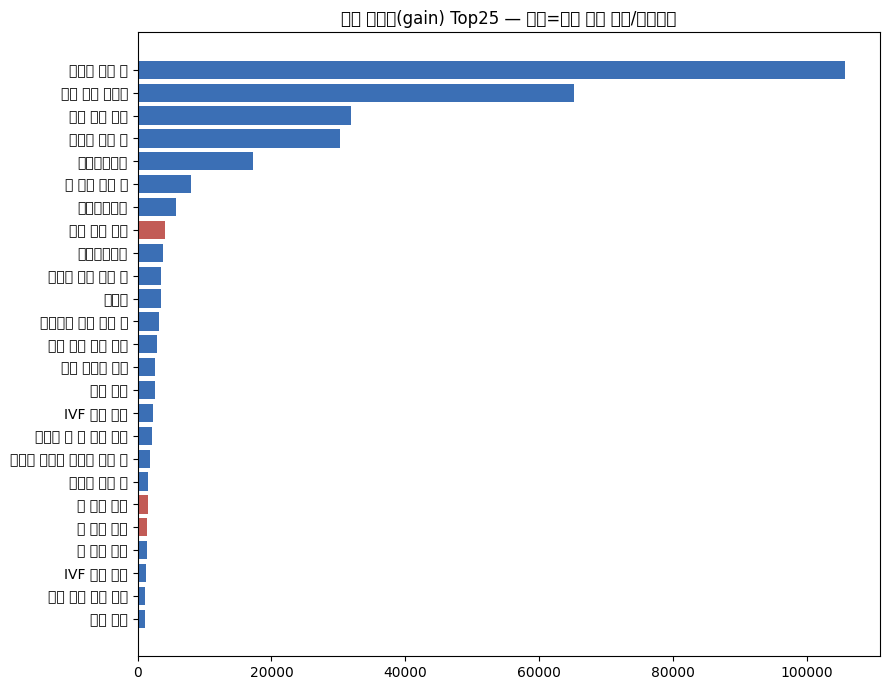

In [10]:
top=imp.head(25)[::-1]
hl=set(HISTORY_LEAK_SUSPECTS)|{CLINIC_COL}
colors=["#c25b56" if i in hl else "#3b6fb5" for i in top.index]
plt.figure(figsize=(9,7)); plt.barh(top.index, top.values, color=colors)
plt.title("피처 중요도(gain) Top25 — 빨강=이력 누수 의심/시기코드"); plt.tight_layout(); plt.show()

## 10. ★ Ablation — multi-seed (mean±std)

각 토글을 **여러 seed로 반복**해 mean±std를 본다. **|Δ| < std → 노이즈(차이 없음)**. `drop_history` 행으로 누수 의심 컬럼 제외 효과도 함께 본다.

⚠️ 무겁다(config × seed × fold). 처음엔 `N_SPLITS=3`, `seeds=(42,7)`로 방향만 보고, 확정 시 풀로.

In [11]:
SEEDS=(42, 7, 2024)
ablation={
    "baseline"            : {},
    "clinic_OFF"          : dict(USE_CLINIC_CODE=False),
    "highmiss_drop"       : dict(HIGH_MISSING="drop"),
    "ratio_OFF"           : dict(ADD_RATIO_FE=False),
    "proc_label"          : dict(PROC_MULTIHOT=False),
    "drop_history(누수검증)": dict(DROP_HISTORY_LEAK=True),
}
rows=[]
for name, ov in ablation.items():
    cfg=dict(CONFIG, **ov)
    Xa, ya, _, _, ca = make_xy(train, test, cfg)
    mean, std, aucs = run_cv_multiseed(Xa, ya, ca, cfg, seeds=SEEDS)
    rows.append({"config":name, "AUC_mean":round(mean,5), "AUC_std":round(std,5), "n_feats":Xa.shape[1]})
    print(f"  {name:<20} {mean:.5f} ± {std:.5f}  feats={Xa.shape[1]}")

res=pd.DataFrame(rows)
base=res.loc[res.config=="baseline","AUC_mean"].iloc[0]
res["Δmean"]=(res["AUC_mean"]-base).round(5)
res["판정"]=np.where(res["Δmean"].abs()<res["AUC_std"], "노이즈", "유의?")
print("\n=== ABLATION (multi-seed) ===")
print(res.to_string(index=False))

dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)


  baseline             0.73946 ± 0.00019  feats=81
dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)


  clinic_OFF           0.73870 ± 0.00015  feats=80
dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


...

  ratio_OFF            0.73965 ± 0.00013  feats=77
dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)


  proc_label           0.73942 ± 0.00010  feats=71
dead: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일'] | sparse: ['난자 해동 경과일']


/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)
/tmp/ipykernel_57/1891914111.py:39: UserWarning: [미인코딩 object 드롭] ['ID']
  if obj_left: warnings.warn(f"[미인코딩 object 드롭] {obj_left}"); df=df.drop(columns=obj_left)


  drop_history(누수검증)   0.73946 ± 0.00022  feats=79

=== ABLATION (multi-seed) ===
            config  AUC_mean  AUC_std  n_feats    Δmean  판정
          baseline   0.73946  0.00019       81  0.00000 노이즈
        clinic_OFF   0.73870  0.00015       80 -0.00076 유의?
     highmiss_drop   0.73955  0.00018       80  0.00009 노이즈
         ratio_OFF   0.73965  0.00013       77  0.00019 유의?
        proc_label   0.73942  0.00010       71 -0.00004 노이즈
drop_history(누수검증)   0.73946  0.00022       79  0.00000 노이즈


## 11. 제출 파일

In [12]:
sub=sample_sub.copy() if sample_sub is not None else pd.DataFrame({ID_COL: ids})
pred_col=[c for c in sub.columns if c!=ID_COL]; pred_col=pred_col[0] if pred_col else "probability"
pmap=dict(zip(ids, test_pred))
if ID_COL in sub.columns: sub[pred_col]=sub[ID_COL].map(pmap)
else: sub[ID_COL]=ids; sub[pred_col]=test_pred
sub.to_csv("submission.csv", index=False)
print("submission.csv:", sub.shape, "| 결측", int(sub[pred_col].isna().sum())); sub.head()

submission.csv: (90067, 2) | 결측 0


,ID,probability
0,TEST_00000,0.001898
1,TEST_00001,0.001913
2,TEST_00002,0.149856
3,TEST_00003,0.108167
4,TEST_00004,0.520562


## 12. 공유 메모 (깃헙용)

- **리크 규정 준수:** 모든 인코더/감지(`fit_preprocessor`)는 train만 fit, `transform`은 적용만. test 행 간 독립 — 심사 코드 검토 대비 자명함.
- **누수 점검(#3):** 9번에서 `총 임신/출산 횟수` 중요도 순위 확인, 10번 `drop_history` 행으로 제외 시 AUC 변화 확인. 두 컬럼이 상위 + 제외 시 AUC 급락이면 **대회 정의(현재 시술 결과 포함 여부) 확인 후 제외 결정**.
- **ablation 판정(#2):** `판정`이 "노이즈"면 그 토글은 결론적으로 무의미 → 건드리지 말 것. "유의?"만 추가 검토.
- **다음 실험 후보:** 나이×난자출처 상호작용, clinic 타깃 인코딩(★ fold 내부 fit 필수), 하이퍼파라미터 튜닝, CatBoost/XGB 블렌딩.